# Algerian Forest Fire Datasets

In [955]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [956]:
df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv", skiprows=1)
# df.drop(columns=["Classes  "], inplace=True) # remove classifciaiton feature
df.dropna(inplace=True) # i removed full na value
df.reset_index()
df.head()
# dependent feature -> FWI

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


## Data Cleaning

In [957]:
# df.info()
print(df.isnull().sum())
# retireve the missing 
# vlaue only
df[df.isnull().any(axis=1)]
# df.loc[:122, "region"] = 0
# df.loc[122:, "region"] = 1
df.shape
# df.iloc[[122]]

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64


(244, 14)

In [958]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          244 non-null    object
 1   month        244 non-null    object
 2   year         244 non-null    object
 3   Temperature  244 non-null    object
 4    RH          244 non-null    object
 5    Ws          244 non-null    object
 6   Rain         244 non-null    object
 7   FFMC         244 non-null    object
 8   DMC          244 non-null    object
 9   DC           244 non-null    object
 10  ISI          244 non-null    object
 11  BUI          244 non-null    object
 12  FWI          244 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 28.6+ KB


In [959]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [960]:
# fix spaces in columns names
df.columns = df.columns.str.strip()
df.columns


Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes'],
      dtype='object')

In [961]:
colInt = ["day", "month", "year", "Temperature", "RH", "Ws"]
for col in colInt:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # handles non-numeric values
    df[col] = df[col].fillna(0).astype(int)  # replaces NaN with 0 and converts to int

colFloat = ["Rain", "FFMC", "DMC", "DC", "ISI", "BUI" , "FWI"]

for col in colFloat:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convert or set invalid to NaN
    df[col] = df[col].fillna(0.0).astype(float)



In [962]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 244 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int32  
 1   month        244 non-null    int32  
 2   year         244 non-null    int32  
 3   Temperature  244 non-null    int32  
 4   RH           244 non-null    int32  
 5   Ws           244 non-null    int32  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           244 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          244 non-null    float64
 13  Classes      244 non-null    object 
dtypes: float64(7), int32(6), object(1)
memory usage: 22.9+ KB


In [963]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,15.696721,7.471311,2003.754098,32.020492,61.786885,15.430328,0.759836,77.523361,14.620492,49.228279,4.722951,16.622131,7.006557
std,8.881839,1.211738,128.805101,4.164764,15.321375,2.975770,1.999677,15.162407,12.403172,47.672572,4.156779,14.239261,7.438889
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,6.750000,2012.000000,30.000000,52.000000,14.000000,0.000000,71.300000,5.775000,10.475000,1.400000,5.975000,0.700000
50%,16.000000,7.500000,2012.000000,32.000000,63.000000,15.000000,0.000000,83.200000,11.250000,33.100000,3.400000,12.250000,4.200000
75%,23.000000,8.000000,2012.000000,35.000000,73.250000,17.000000,0.500000,88.300000,20.750000,68.150000,7.225000,22.525000,11.375000
max,31.000000,9.000000,2012.000000,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000


In [964]:
# plt.figure(figsize=(10,10))
# sns.heatmap(df.corr(), annot=True)

## Save the clead datasets

In [965]:
df.to_csv("Algerian_Cleaned.csv", index=False)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [966]:
# drop day month heare
# df.drop(columns=["day", "month", "year"], inplace=True)

In [967]:
df.head()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [968]:
df["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
Classes            1
not fire           1
not fire           1
Name: count, dtype: int64

In [969]:
df["Classes"] = np.where(df["Classes"].str.contains("not") == True, 0, 1)

In [970]:
df["Classes"].value_counts()


Classes
1    138
0    106
Name: count, dtype: int64

## Plots

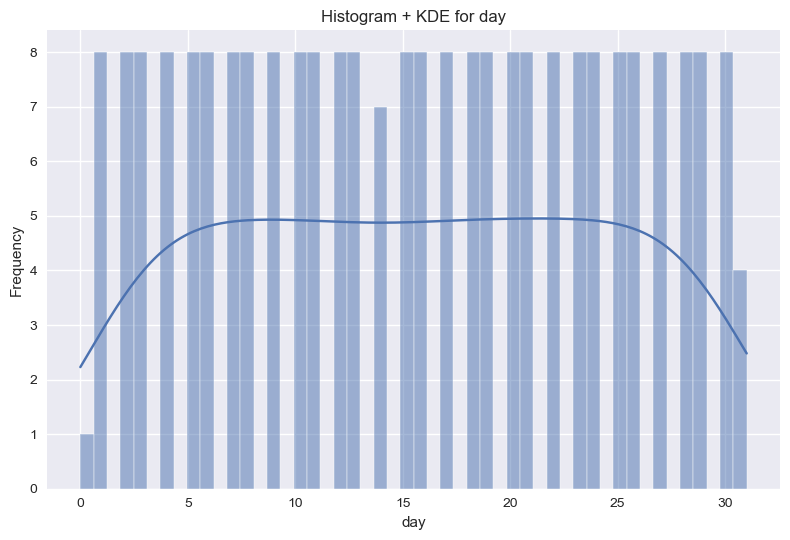

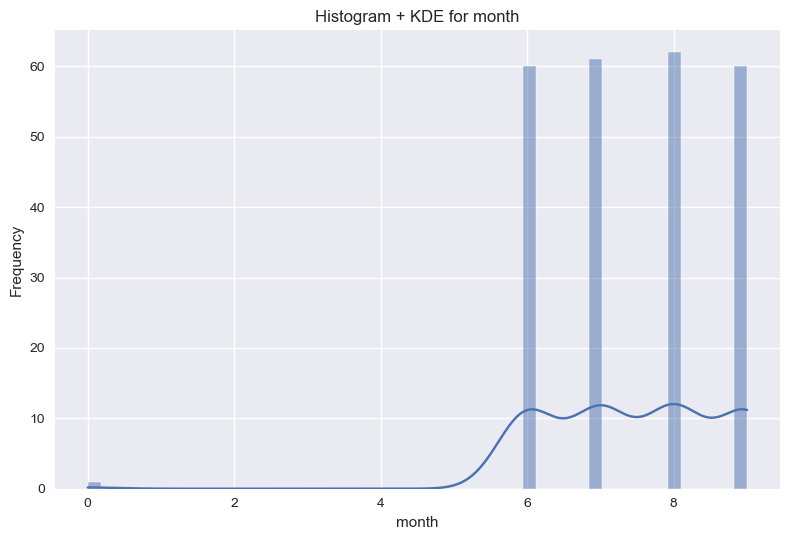

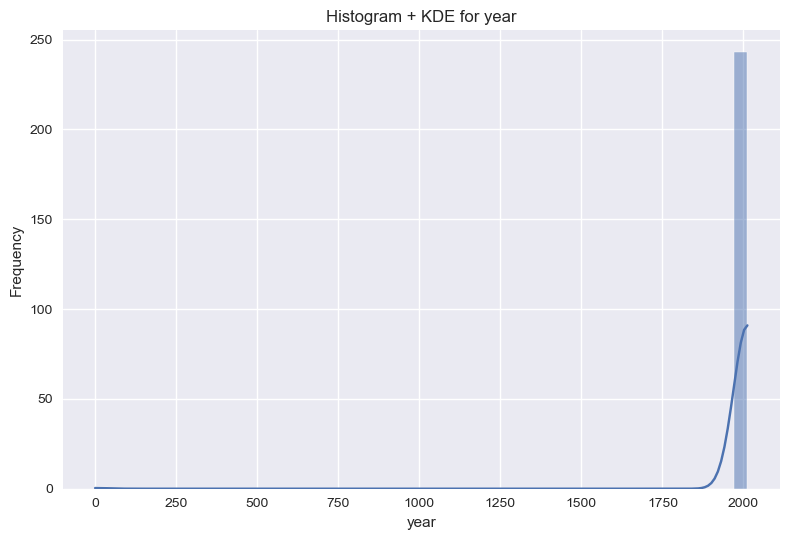

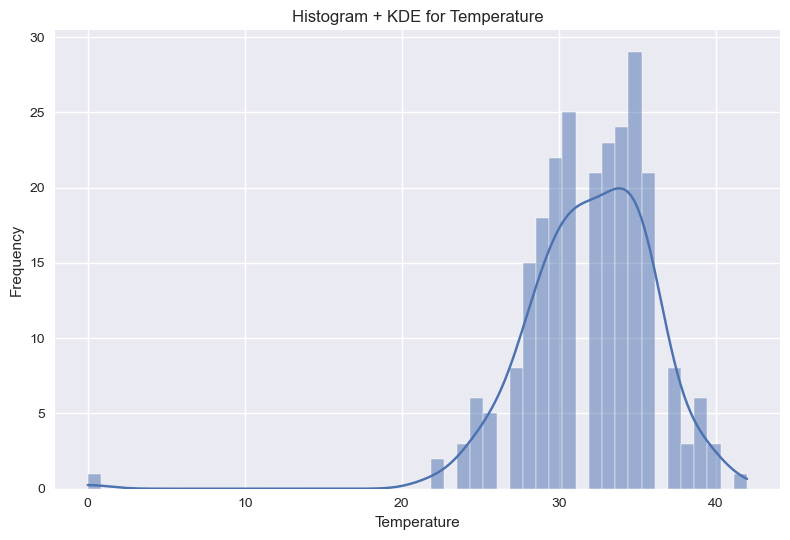

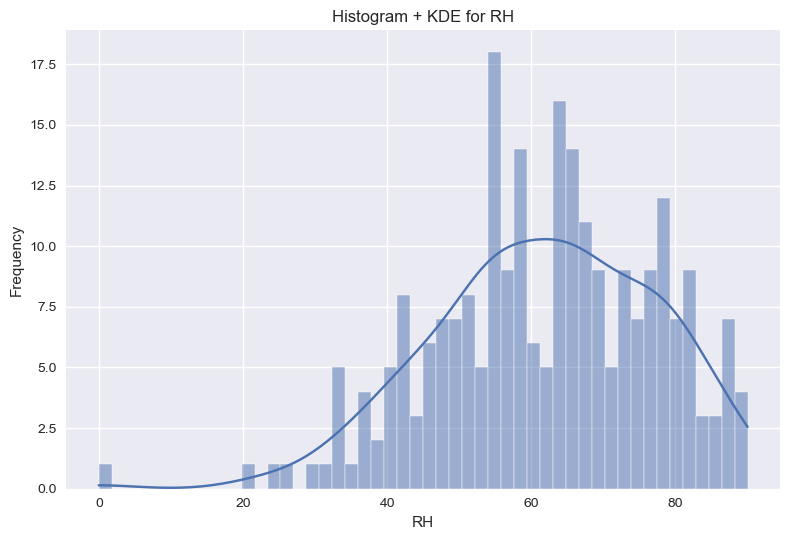

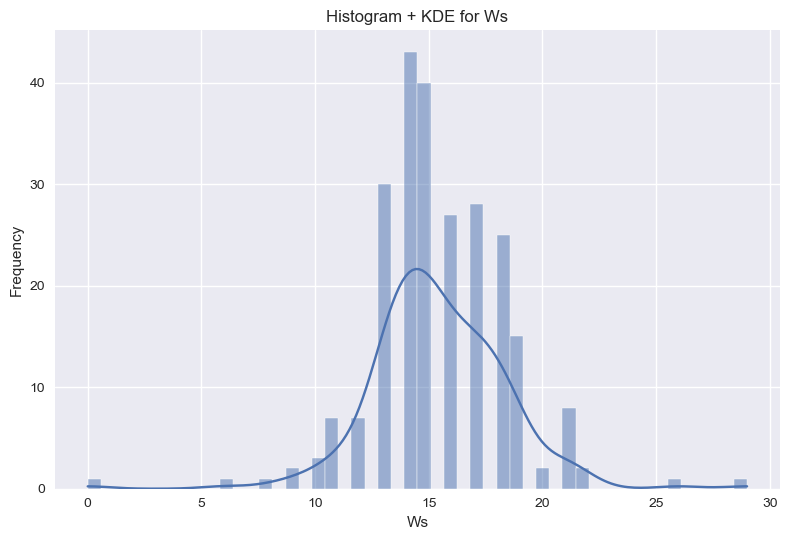

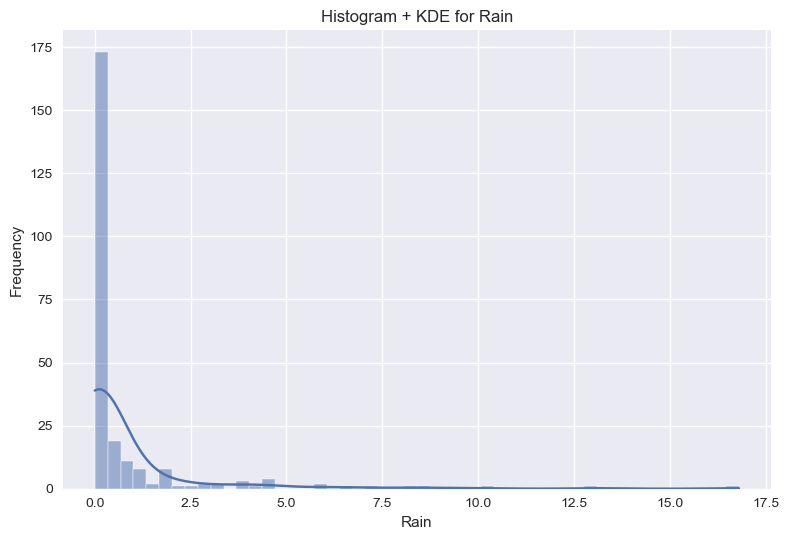

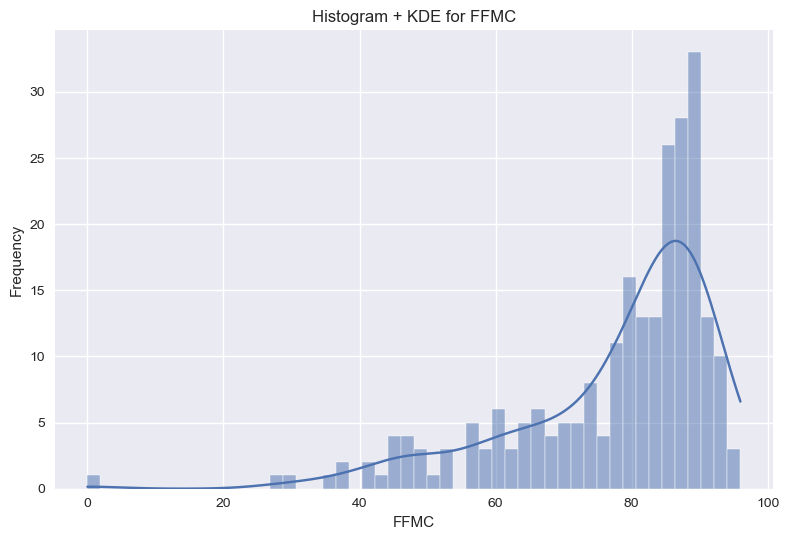

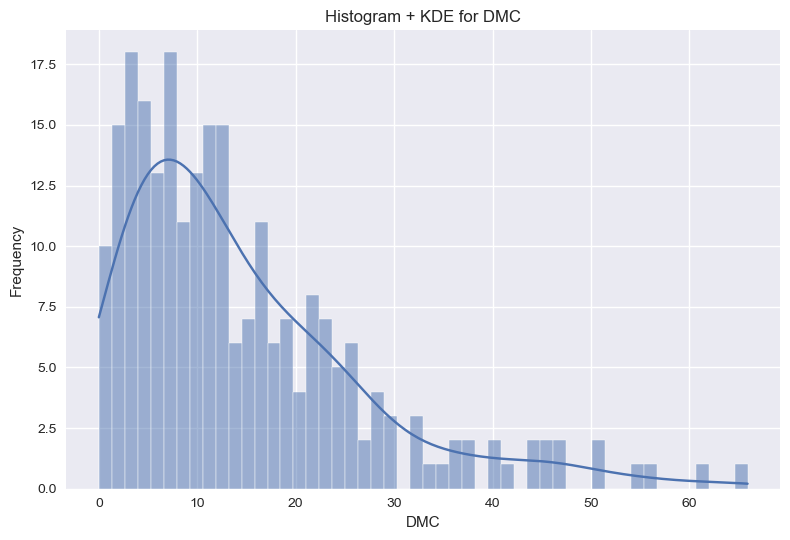

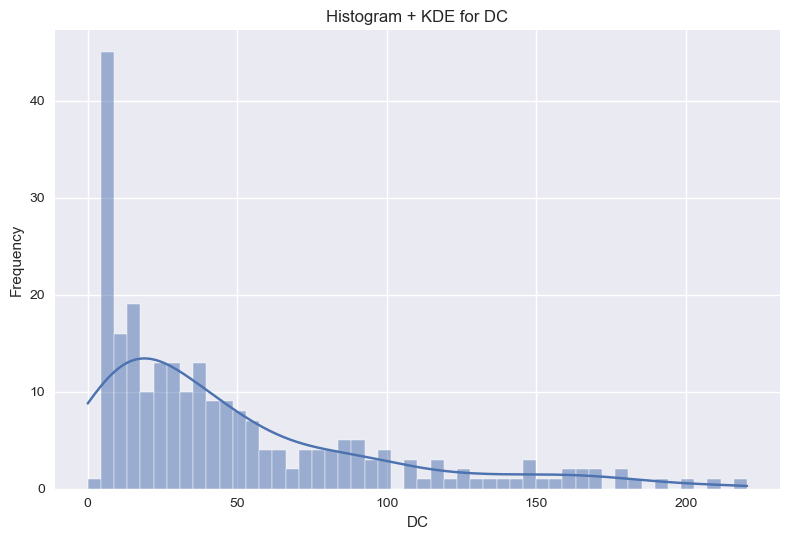

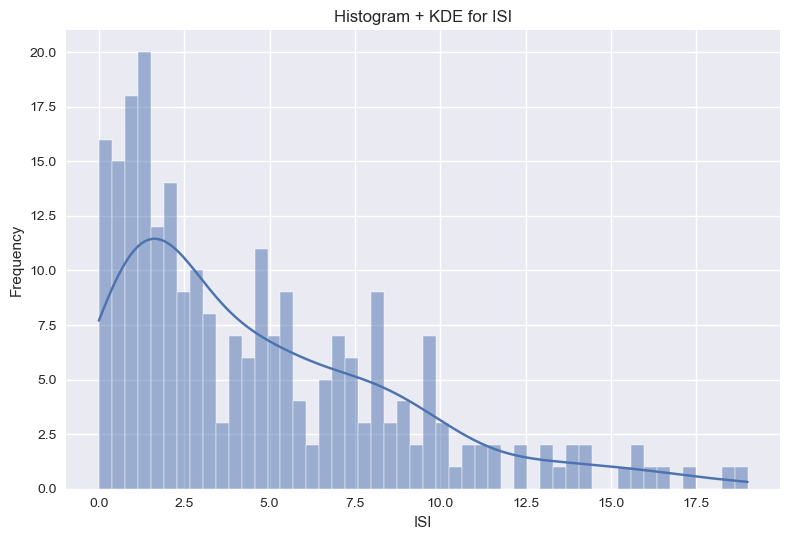

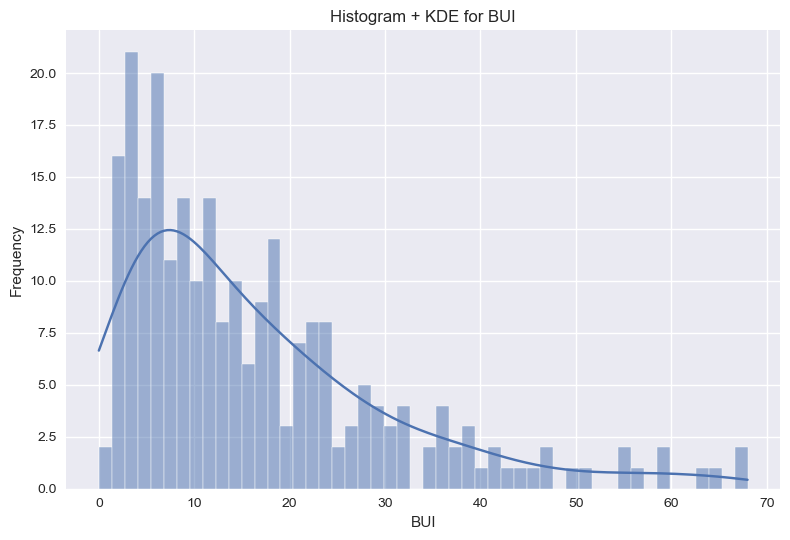

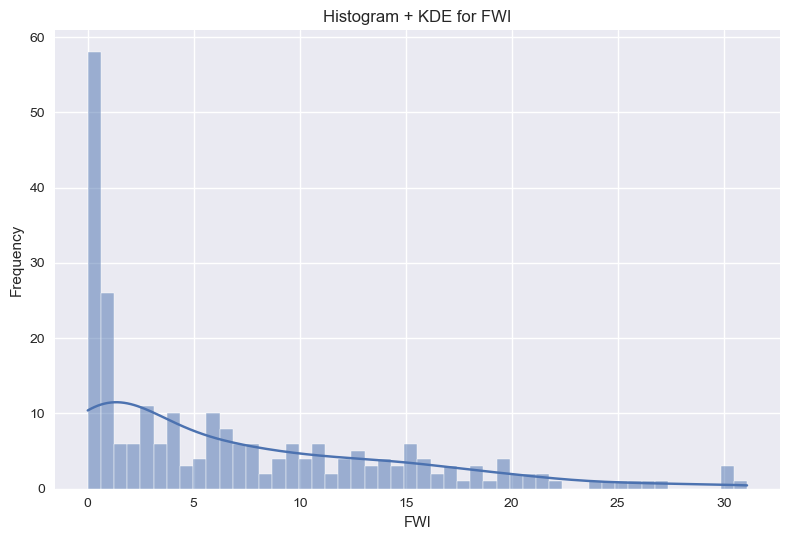

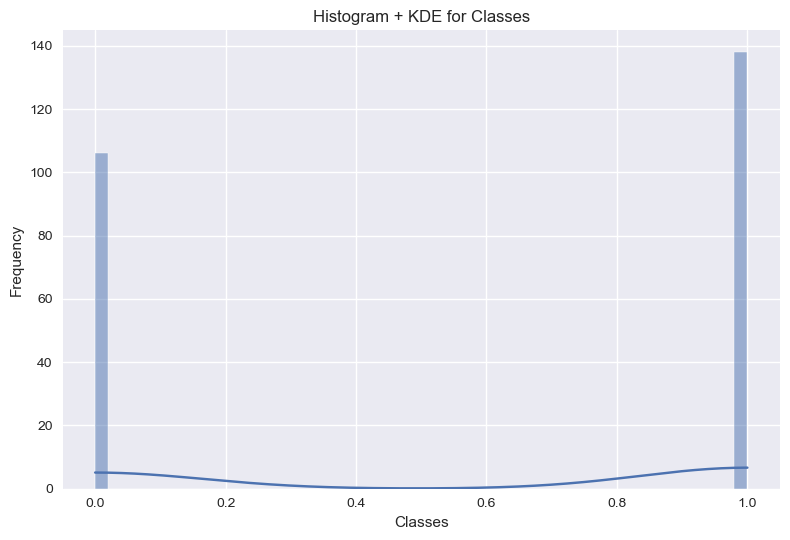

In [971]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Histogram + KDE for {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


In [972]:
# sns.pairplot(df)

In [973]:
# pie chat
percent = df["Classes"].value_counts(normalize=True) * 100
classlabels = ["Fire", "NotFire"]

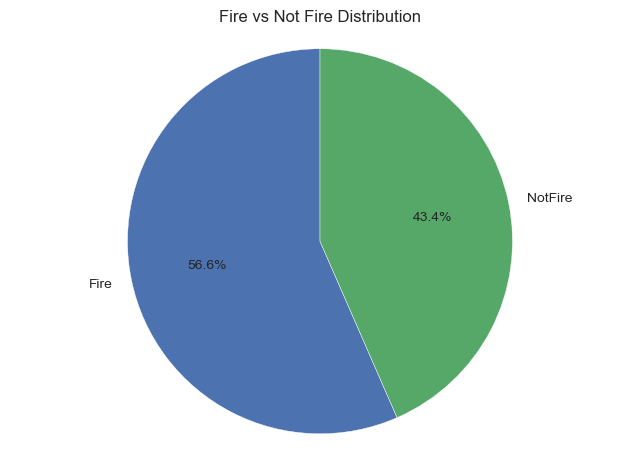

In [974]:
plt.pie(x=percent, labels=classlabels, autopct='%1.1f%%', startangle=90)
plt.title("Fire vs Not Fire Distribution")
plt.axis('equal')  # Equal aspect ratio to make the pie circular
plt.show()

<Axes: >

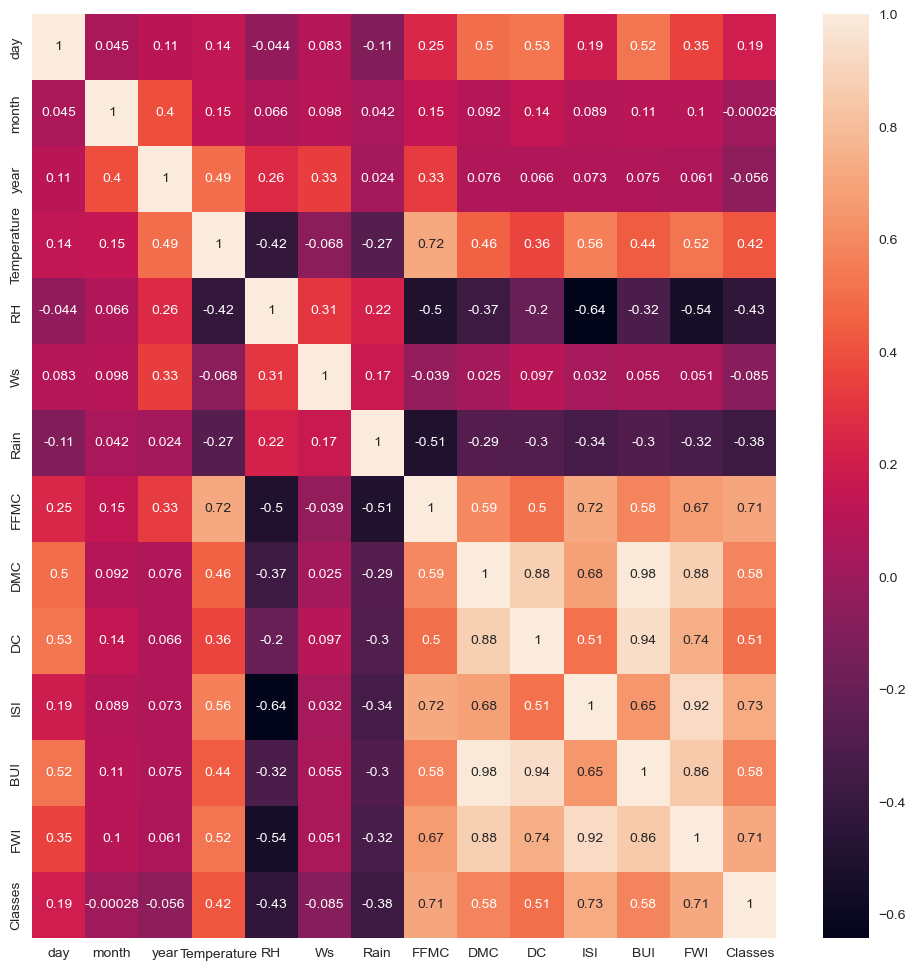

In [975]:
# corr
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), annot=True)

<Axes: ylabel='FWI'>

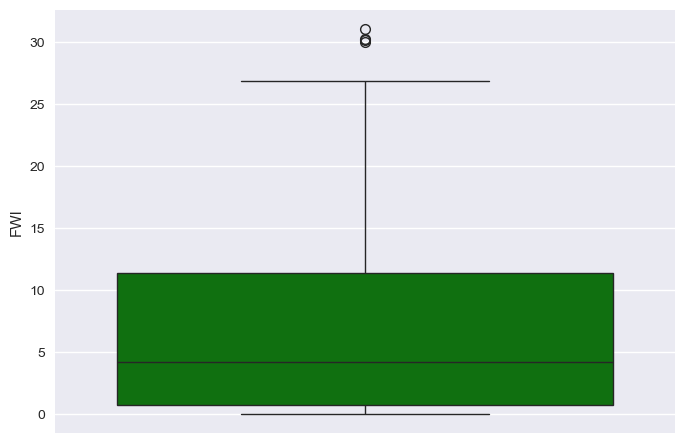

In [976]:
# box plots based on FWI
sns.boxplot(df["FWI"], color="green")

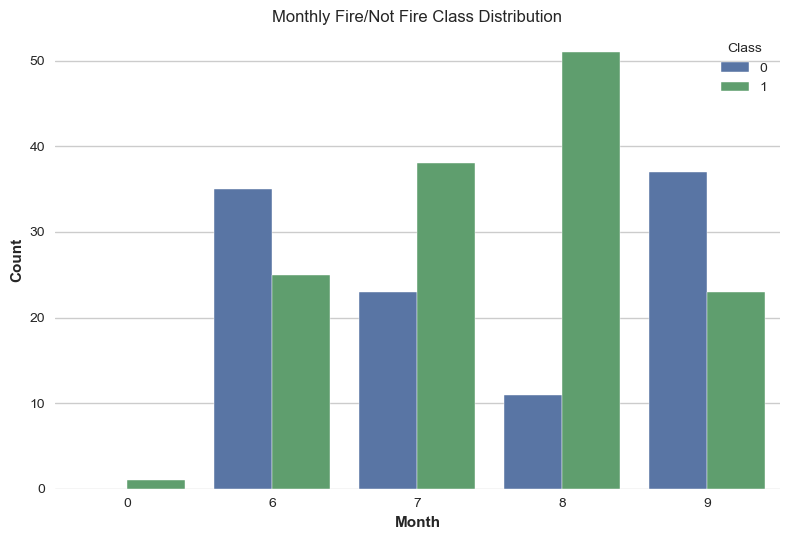

In [977]:
sns.set_style("whitegrid")

sns.countplot(x="month", hue="Classes", data=df)
plt.title("Monthly Fire/Not Fire Class Distribution")
plt.xlabel("Month", weight="bold")
plt.ylabel("Count", weight="bold")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

## Feature Selctions

In [978]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0


In [979]:
df.drop(columns=["day", "month", "year"], inplace=True)

In [980]:
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
Temperature,1.000000,-0.418807,-0.068453,-0.271674,0.717924,0.458459,0.359201,0.559660,0.435670,0.521645,0.420093
RH,-0.418807,1.000000,0.308634,0.221023,-0.503028,-0.373777,-0.201492,-0.642489,-0.321329,-0.544372,-0.431302
Ws,-0.068453,0.308634,1.000000,0.169792,-0.038749,0.024579,0.096570,0.032367,0.054569,0.050642,-0.084599
Rain,-0.271674,0.221023,0.169792,1.000000,-0.505509,-0.286006,-0.295656,-0.344668,-0.297084,-0.322251,-0.379758
FFMC,0.717924,-0.503028,-0.038749,-0.505509,1.000000,0.593340,0.499969,0.721035,0.582209,0.671439,0.707117
DMC,0.458459,-0.373777,0.024579,-0.286006,0.593340,1.000000,0.876510,0.682220,0.982349,0.876332,0.578790
DC,0.359201,-0.201492,0.096570,-0.295656,0.499969,0.876510,1.000000,0.511014,0.942242,0.740555,0.505457
ISI,0.559660,-0.642489,0.032367,-0.344668,0.721035,0.682220,0.511014,1.000000,0.646042,0.923164,0.727968
BUI,0.435670,-0.321329,0.054569,-0.297084,0.582209,0.982349,0.942242,0.646042,1.000000,0.858528,0.579841
FWI,0.521645,-0.544372,0.050642,-0.322251,0.671439,0.876332,0.740555,0.923164,0.858528,1.000000,0.713357


In [981]:
cols = np.array(df.columns)
print(cols)

['Temperature' 'RH' 'Ws' 'Rain' 'FFMC' 'DMC' 'DC' 'ISI' 'BUI' 'FWI'
 'Classes']


In [982]:
arr = np.array(df.corr())
print(arr[0])

[ 1.         -0.4188066  -0.06845273 -0.27167365  0.71792351  0.45845914
  0.35920081  0.55965957  0.43566958  0.52164451  0.42009308]


In [983]:
check = set()  # Use set to automatically handle uniqueness

for i in range(len(arr)):
    for j in range(len(arr[i])):
        if i != j and arr[i][j] > 0.80:
            pair = tuple(sorted([i, j]))  # always (smaller, larger)
            check.add(pair)


In [984]:
check = list(check)
print(check)

[(5, 8), (6, 8), (7, 9), (8, 9), (5, 6), (5, 9)]


In [985]:
ob = {}
for item in check:
    if item[0] in ob:
        ob[item[0]].append(item[1])
    else:
        ob[item[0]] = [item[1]]

# print(ob)
# fill the cols
cols_map = {}
for item in ob:
    new_key = cols[item]
    cols_map[new_key] = []
    for i in range(len(ob[item])):
        col = cols[ob[item][i]]
        cols_map[new_key].append(col)
        
    
print(cols_map)



{'DMC': ['BUI', 'DC', 'FWI'], 'DC': ['BUI'], 'ISI': ['FWI'], 'BUI': ['FWI']}


In [986]:
target_col = "FWI"  # Set your output column name

cols_to_drop = set()

for key, correlated in cols_map.items():
    for col in correlated:
        if col != key and col != target_col and col not in cols_to_drop:
            cols_to_drop.add(col)

# Also make sure not to drop the target column even if it was used as a key
if target_col in cols_to_drop:
    cols_to_drop.remove(target_col)

# Drop from the original DataFrame
df.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns:", cols_to_drop)
print("DataFrame shape:", df.shape)


Dropped columns: {'DC', 'BUI'}
DataFrame shape: (244, 9)


In [987]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,FWI,Classes
0,29,57,18,0.0,65.7,3.4,1.3,0.5,0
1,29,61,13,1.3,64.4,4.1,1.0,0.4,0
2,26,82,22,13.1,47.1,2.5,0.3,0.1,0
3,25,89,13,2.5,28.6,1.3,0.0,0.0,0
4,27,77,16,0.0,64.8,3.0,1.2,0.5,0


In [988]:
# devide the dependenet and independent feature
X = df.iloc[:, :-2]
y = df.iloc[:, -2]
X.shape, y.shape
# y

((244, 7), (244,))

In [989]:
# Train_test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape,y_train.shape,  X_test.shape, y_test.shape

((195, 7), (195,), (49, 7), (49,))

Mean Squared Error: 0.44
R² Score: 0.99


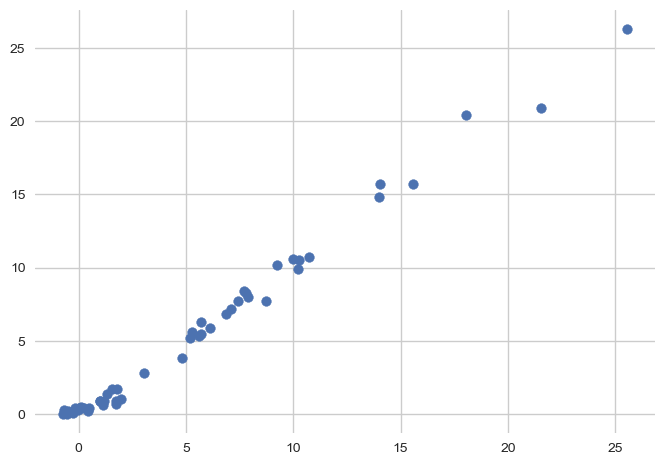

In [990]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
# Predict
y_pred = lr_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
plt.scatter(y_pred, y_test)

Mean Squared Error: 1.69
R² Score: 0.96


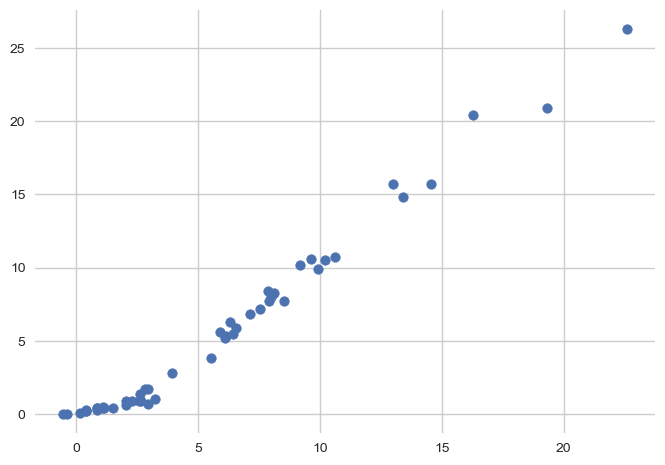

In [991]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", Lasso())
])

lr_pipeline.fit(X_train, y_train)
# Predict
y_pred = lr_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
plt.scatter(y_pred, y_test)

Mean Squared Error: 0.46
R² Score: 0.99


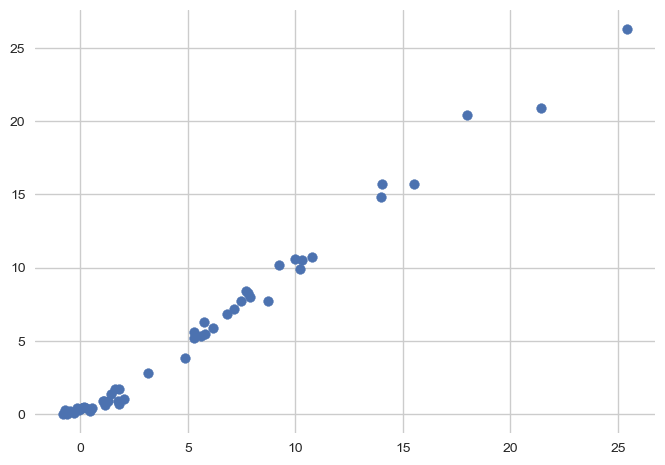

In [992]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", Ridge())
])

lr_pipeline.fit(X_train, y_train)
# Predict
y_pred = lr_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
plt.scatter(y_pred, y_test)

Mean Squared Error: 4.70
R² Score: 0.88


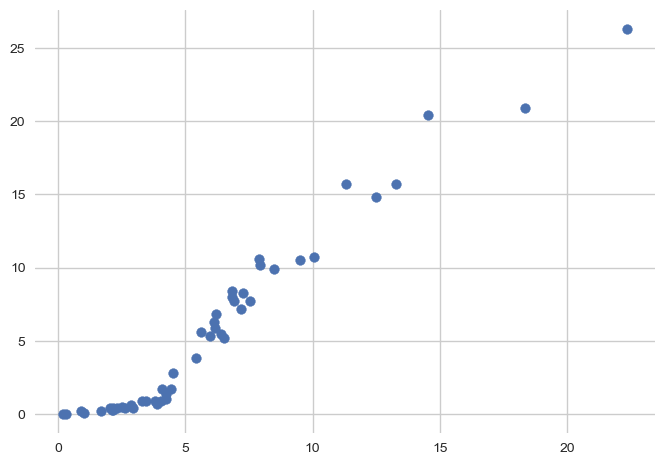

In [993]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=True)),
    ("lr", ElasticNet())
])

lr_pipeline.fit(X_train, y_train)
# Predict
y_pred = lr_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
plt.scatter(y_pred, y_test)


Mean Squared Error: 0.32
R² Score: 0.99


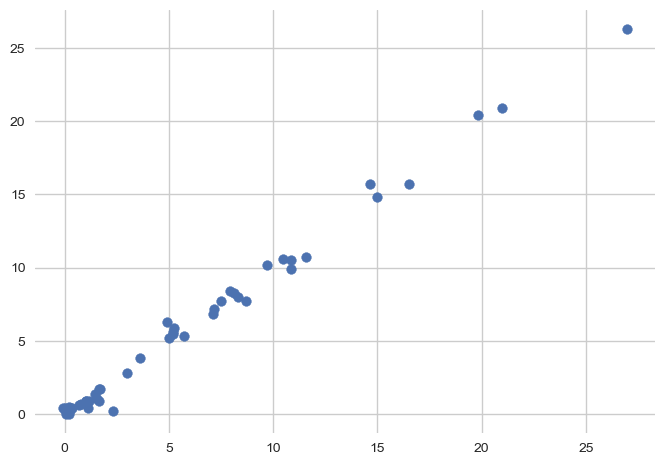

In [994]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=True)),
    ("lr", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
# Predict
y_pred = lr_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")
plt.scatter(y_pred, y_test)


In [995]:
print(pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred}).head())


   Actual  Predicted
0     8.4   7.925851
1     7.2   7.145032
2     0.5   0.199172
3     5.9   5.225272
4    14.8  14.977442


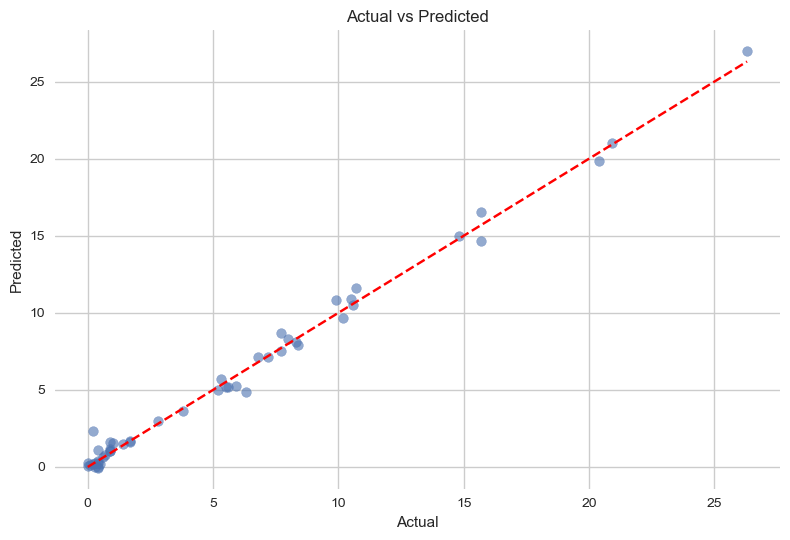

In [996]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()


## Cross validaiton (Hyper parameter tuning)

In [997]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,FWI,Classes
0,29,57,18,0.0,65.7,3.4,1.3,0.5,0
1,29,61,13,1.3,64.4,4.1,1.0,0.4,0
2,26,82,22,13.1,47.1,2.5,0.3,0.1,0
3,25,89,13,2.5,28.6,1.3,0.0,0.0,0
4,27,77,16,0.0,64.8,3.0,1.2,0.5,0


In [998]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Create pipeline with scaling and LassoCV
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42))
])

# Train
lasso_pipeline.fit(X_train, y_train)

# Predict
y_pred = lasso_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best alpha: {lasso_pipeline.named_steps['lasso'].alpha_}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Best alpha: 0.007004884061380417
Mean Squared Error: 0.45
R² Score: 0.99


In [1002]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Create pipeline with scaling and LassoCV
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", RidgeCV(cv=5))
])

# Train
lasso_pipeline.fit(X_train, y_train)

# Predict
y_pred = lasso_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best alpha: {lasso_pipeline.named_steps['lasso'].alpha_}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")


Best alpha: 1.0
Mean Squared Error: 0.46
R² Score: 0.9882


In [ ]:
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Create pipeline with scaling and LassoCV
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", RidgeCV(cv=5))
])

# Train
lasso_pipeline.fit(X_train, y_train)

# Predict
y_pred = lasso_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best alpha: {lasso_pipeline.named_steps['lasso'].alpha_}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")


In [1003]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Create pipeline with scaling and LassoCV
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", RidgeCV(cv=5))
])

# Train
lasso_pipeline.fit(X_train, y_train)

# Predict
y_pred = lasso_pipeline.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Best alpha: {lasso_pipeline.named_steps['lasso'].alpha_}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")


Best alpha: 1.0
Mean Squared Error: 0.46
R² Score: 0.9882
